In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
uploaded = files.upload()



Saving processed_airbnb.csv to processed_airbnb.csv


Uploading original kaggle dataset

In [ ]:
from google.colab import files

uploaded = files.upload()

Saving ogdataset.csv to ogdataset.csv


Grabbing the dataset and keeping only the features we want into a file called processed_airbnb_all_reviews.csv

In [ ]:

import pandas as pd

df = pd.read_csv(
    'ogdataset.csv',
    encoding='latin1'
)

# Make sure rating is numeric
df["review_scores_rating"] = pd.to_numeric(
    df["review_scores_rating"],
    errors="coerce"
)

# Keep rows where rating is either real rating or 0
df = df[df["review_scores_rating"].notna()]

selected_features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'cleaning_fee',
    'host_response_rate',
    'room_type_Entire home/apt',
    'room_type_Private room',
    'instant_bookable_t',
    '"Air conditioning"',
    '"Coffee maker"',
    '"Cooking basics"',
    '"Family/kid friendly"',
    '"Free parking on premises"',
    '"Hot water"',
    '"Private entrance"',
    '"Self Check-In"',
    '"Wireless Internet"',
    'Kitchen',
    'longitude',
    'latitude',
    '"Hair dryer"',
    '"Laptop friendly workspace"',
    'log_price',
    'Iron',
    'Shampoo',
    'Hangers',
    'Dryer',
    'Washer',
    '"First aid kit"',
    'Essentials',
    '"Smoke detector"',
    'TV'
]

final_columns = selected_features + ['review_scores_rating']

processed_df = df[final_columns].copy()

feature_columns = [
    col for col in processed_df.columns
    if col != 'review_scores_rating'
]

processed_df[feature_columns] = processed_df[feature_columns].fillna(0)

print("Rows with ratings:", (processed_df["review_scores_rating"] > 0).sum())
print("Rows with no reviews:", (processed_df["review_scores_rating"] == 0).sum())

processed_df.to_csv(
    "processed_airbnb_all_reviews.csv",
    index=False
)

files.download("processed_airbnb_all_reviews.csv")

Rows with ratings: 19741
Rows with no reviews: 5717


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Uploading the processed csv

LINEAR REGRESSION

Training the model based on the rows that do have reviews, dropping those that have no reviews (0)
Calculate MSE, RMSE, and R²

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score


# Load dataset
df = pd.read_csv(
    'processed_airbnb_all_reviews.csv'
)


# Make sure ratings are numeric
df['review_scores_rating'] = pd.to_numeric(
    df['review_scores_rating'],
    errors='coerce'
)


# Rows with ratings
rated_df = df[df['review_scores_rating'] > 0].copy()


# Rows with no reviews
unrated_df = df[df['review_scores_rating'] == 0].copy()

print("Rows with ratings:", len(rated_df))
print("Rows with no reviews:", len(unrated_df))


# Features and target
X = rated_df.drop(columns=['review_scores_rating'])
y = rated_df['review_scores_rating']


# Convert categorical columns into numeric columns
X = pd.get_dummies(X)


# Fill missing values
X = X.fillna(0)


# Split into training/testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=0
)


# Train model
model = LinearRegression()
model.fit(X_train, y_train)


# Predict test set
predictions = model.predict(X_test)

# Evaluate model
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, predictions)

print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)



Rows with ratings: 19741
Rows with no reviews: 5717
MSE: 61.975369109267945
RMSE: 7.872443655515608
R²: 0.03818120963767013


Using the trained model to predict all review scores including the calculated error

In [ ]:
# Train final model using ALL rated rows
final_model = LinearRegression()
final_model.fit(X, y)


# Predict ratings for rows WITH ratings
rated_df['predicted_review_score'] = final_model.predict(X)

# Calculate prediction error
rated_df['prediction_error'] = abs(
    rated_df['review_scores_rating']
    - rated_df['predicted_review_score']
)


# Predict ratings for rows WITHOUT reviews
if len(unrated_df) > 0:

    X_unrated = unrated_df.drop(columns=['review_scores_rating'])

    X_unrated = pd.get_dummies(X_unrated)

    # Match columns with training data
    X, X_unrated = X.align(
        X_unrated,
        join='left',
        axis=1,
        fill_value=0
    )

    X_unrated = X_unrated.fillna(0)

    unrated_predictions = final_model.predict(X_unrated)

    unrated_df['predicted_review_score'] = unrated_predictions
    unrated_df['prediction_error'] = np.nan

else:
    unrated_df['predicted_review_score'] = np.nan


# Combine back together
final_df = pd.concat([rated_df, unrated_df])


# Restore original row order
final_df = final_df.sort_index()


# Final score:
# keep original rating if it exists
# otherwise use predicted rating
final_df['final_review_score'] = final_df['review_scores_rating']

final_df.loc[
    final_df['review_scores_rating'] == 0,
    'final_review_score'
] = final_df['predicted_review_score']


# Show dataframe in original order
display(
    final_df[
        [
            'review_scores_rating',
            'predicted_review_score',
            'prediction_error',
            'final_review_score'
        ]
    ].head(20)
)


,review_scores_rating,predicted_review_score,prediction_error,final_review_score
0,97.0,94.714737,2.285263,97.000000
1,80.0,95.576362,15.576362,80.000000
2,100.0,94.697232,5.302768,100.000000
3,94.0,95.205193,1.205193,94.000000
4,0.0,94.915263,NaN,94.915263
5,98.0,95.149681,2.850319,98.000000
6,97.0,92.291886,4.708114,97.000000
7,93.0,93.098216,0.098216,93.000000
8,92.0,95.720644,3.720644,92.000000
9,0.0,94.063744,NaN,94.063744


Generating scatterplot to show predicted vs actual review scores

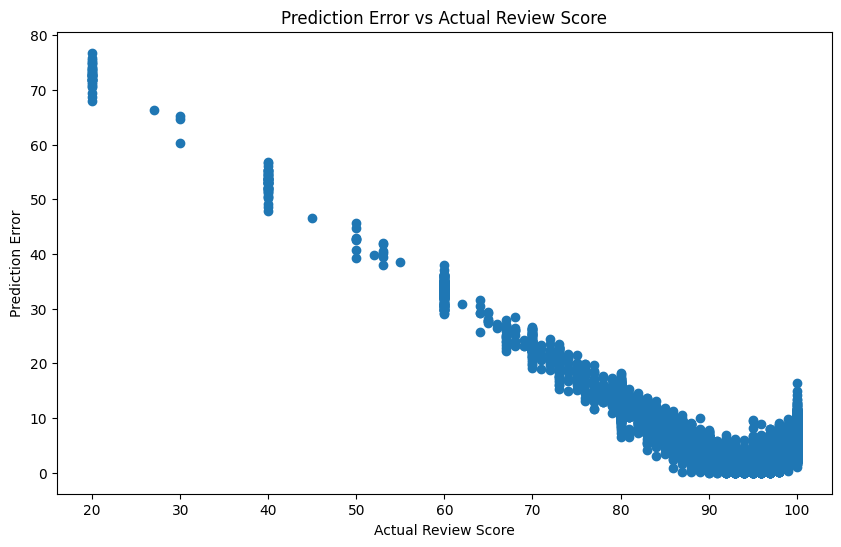

In [ ]:
# Only rows with actual ratings
rated_only = final_df[
    final_df['review_scores_rating'] > 0
]


# Scatter plot of prediction error
plt.figure(figsize=(10, 6))

plt.scatter(
    rated_only['review_scores_rating'],
    rated_only['prediction_error']
)

plt.xlabel("Actual Review Score")
plt.ylabel("Prediction Error")
plt.title("Prediction Error vs Actual Review Score")

plt.show()

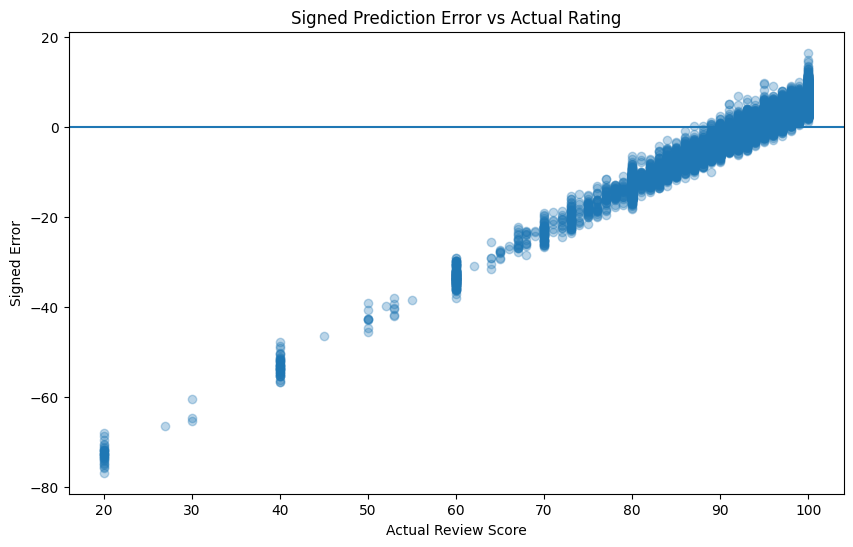

In [ ]:
# below 0 = model predicted too high
# above 0 = model predicted too low
# near 0 = accurate prediction

rated_df['signed_error'] = (
    rated_df['review_scores_rating']
    - rated_df['predicted_review_score']
)
plt.figure(figsize=(10,6))

plt.scatter(
    rated_df['review_scores_rating'],
    rated_df['signed_error'],
    alpha=0.3
)

plt.axhline(y=0)

plt.xlabel("Actual Review Score")
plt.ylabel("Signed Error")
plt.title("Signed Prediction Error vs Actual Rating")

plt.show()

In [ ]:
df = pd.read_csv("ProcessedDataTrain.csv", encoding='latin1')

FileNotFoundError: [Errno 2] No such file or directory: 'ProcessedDataTrain.csv'

In [ ]:
print(df.shape)
print(df.head())
print(df.info())

In [ ]:
df = df[df["review_scores_rating"] > 0]
numeric_df = df.select_dtypes(include=['int64', 'float64'])
target = "review_scores_rating"
correlations = numeric_df.corr()[target].sort_values(ascending=False)

print(correlations)

In [ ]:
selected_features = correlations[abs(correlations) > 0.05]

print(selected_features)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_features = correlations.abs().sort_values(ascending=False).head(15).index

plt.figure(figsize=(12,10))
sns.heatmap(df[top_features].corr(), annot=True, cmap="coolwarm")
plt.show()


In [ ]:
selected_features = [
    'accommodates',
    'bathrooms',
    'bedrooms',
    'beds',
    'cleaning_fee',
    'host_response_rate',
    'room_type_Entire home/apt',
    'room_type_Private room',
    'instant_bookable_t',
    '"Air conditioning"',
    '"Coffee maker"',
    '"Cooking basics"',
    '"Family/kid friendly"',
    '"Free parking on premises"',
    '"Hot water"',
    '"Private entrance"',
    '"Self Check-In"',
    '"Wireless Internet"',
    'Kitchen',
    'longitude',
    'latitude',
    '"Hair dryer"',
    '"Laptop friendly workspace"',
    'log_price',
    'Iron',
    'Shampoo',
    'Hangers',
    'Dryer',
    'Washer',
    '"First aid kit"',
    'Essentials',
    '"Smoke detector"',
    'TV'
]

final_columns = selected_features + ['review_scores_rating']

processed_df = df[final_columns]
processed_df = processed_df.dropna()
processed_df.to_csv("processed_airbnb.csv", index=False)
#files.download("processed_airbnb.csv")

#Polynomial Regressions

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

from google.colab import files

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:

df = pd.read_csv("processed_airbnb.csv", encoding='latin1')
X = df.drop(columns=["review_scores_rating"])
y = df["review_scores_rating"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

def polynomial_regression(degree):
  model = Pipeline([
      ("scaler", StandardScaler()),
      ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
      ("linear", LinearRegression())
  ])

  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_mse = mean_squared_error(y_train, y_train_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  train_r2 = r2_score(y_train, y_train_pred)
  test_r2 = r2_score(y_test, y_test_pred)

  print(f"Polynomial Degree {degree}")
  print(f"Train MSE: {train_mse:.4f}")
  print(f"Test MSE: {test_mse:.4f}")
  print(f"Train R2: {train_r2:.4f}")
  print(f"Test R2: {test_r2:.4f}")

  return model

poly2_model = polynomial_regression(2)
poly3_model = polynomial_regression(3)

Polynomial Degree 2
Train MSE: 56.1567
Test MSE: 57.1797
Train R2: 0.0897
Test R2: 0.0514
Polynomial Degree 3
Train MSE: 46.7861
Test MSE: 1581071.9807
Train R2: 0.2416
Test R2: -26229.2517


Try with L2 Ridge

In [ ]:
from sklearn.linear_model import Ridge

def ridge_model(degree):
  model = Pipeline([
      ("scaler", StandardScaler()),
      ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
      ("ridge", Ridge(alpha=1))
  ])

  model.fit(X_train, y_train)

  y_train_pred = model.predict(X_train)
  y_test_pred = model.predict(X_test)

  train_mse = mean_squared_error(y_train, y_train_pred)
  test_mse = mean_squared_error(y_test, y_test_pred)
  train_r2 = r2_score(y_train, y_train_pred)
  test_r2 = r2_score(y_test, y_test_pred)

  print(f"Polynomial Degree {degree}")
  print(f"Train MSE: {train_mse:.4f}")
  print(f"Test MSE: {test_mse:.4f}")
  print(f"Train R2: {train_r2:.4f}")
  print(f"Test R2: {test_r2:.4f}")

  return model

ridge2_model = ridge_model(2)
ridge3_model = ridge_model(3)

Polynomial Degree 2
Train MSE: 56.1567
Test MSE: 57.1793
Train R2: 0.0897
Test R2: 0.0514


Find the features with biggest contribution and form a smaller set of features

In [ ]:
feature_names = ridge2_model.named_steps["poly"].get_feature_names_out(X.columns)

coefficients = ridge2_model.named_steps["ridge"].coef_

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

coef_df["Abs_Coefficient"] = np.abs(coef_df["Coefficient"])

coef_df = coef_df.sort_values(
    by="Abs_Coefficient",
    ascending=False
)

top_features = coef_df.head(15)

print(top_features)


                         Feature  Coefficient  Abs_Coefficient
0             host_response_rate     2.859615         2.859615
33            latitude longitude    -1.482938         1.482938
11          host_response_rate^2     1.456014         1.456014
4                      log_price     1.440715         1.440715
41                   longitude^2    -1.192093         1.192093
1                   accommodates    -1.188182         1.188182
2                       latitude    -0.733159         0.733159
32                    latitude^2     0.713322         0.713322
38               latitude Washer     0.570557         0.570557
46              longitude Washer    -0.512851         0.512851
45               longitude Dryer     0.507506         0.507506
70          Dryer "Coffee maker"    -0.504700         0.504700
53              log_price Washer    -0.504141         0.504141
52               log_price Dryer     0.487949         0.487949
63  room_type_Private room Dryer     0.483772         0

In [ ]:
smaller_features = [
    'host_response_rate',
    'accommodates',

    'latitude',
    'longitude',
    'log_price',
    'beds',
    'room_type_Private room',
    'Dryer',
    'Washer',
    '"Cooking basics"',
    '"Coffee maker"'
]

X = df[smaller_features]
y = df['review_scores_rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
ridge2_model = ridge_model(2)
ridge3_model = ridge_model(3)


Polynomial Degree 2
Train MSE: 58.8984
Test MSE: 57.8049
Train R2: 0.0453
Test R2: 0.0410
Polynomial Degree 3
Train MSE: 58.1772
Test MSE: 58.2409
Train R2: 0.0570
Test R2: 0.0338


# Neural Network

Start with a simple Neural Network with 2 hiddent layers. First have 64 ndoes and second have 32, output1 with sigmoid activation function, then scale the output to be between 0 to 100

In [ ]:
df = pd.read_csv("processed_airbnb.csv", encoding="latin1")

X = df.drop(columns=["review_scores_rating"])
y = df["review_scores_rating"]
y_scaled = y / 100.0 #scale down to be between 0 to 1 since we output sigmoid which is 0 to 1

X_train, X_test, y_train, y_test = train_test_split(X, y_scaled, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100
y_train_actual = y_train * 100
y_test_actual = y_test * 100
#scale the output values back to between 0 and 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - loss: 0.1272 - mse: 0.1272 - val_loss: 0.1257 - val_mse: 0.1257
Epoch 2/3
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - loss: 0.1217 - mse: 0.1217 - val_loss: 0.1235 - val_mse: 0.1235
Epoch 3/3
1483/1483 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.1201 - mse: 0.1201 - val_loss: 0.1233 - val_mse: 0.1233
1853/1853 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step
464/464 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Train MSE: 1193.4742711360454
Test MSE: 1210.449605775499
Train RMSE: 34.54669696419681
Test RMSE: 34.791516290261036
Train R2: 0.2517405185755254
Test R2: 0.23780806497250162


Use droopout to prevent overdependence one any singular nodes

In [ ]:
from tensorflow.keras.layers import Dropout


model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100

y_train_actual = y_train * 100
y_test_actual = y_test * 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


Saving processed_airbnb.csv to processed_airbnb.csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0076 - mse: 0.0076 - val_loss: 0.0059 - val_mse: 0.0059
Epoch 2/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0063 - mse: 0.0063 - val_loss: 0.0064 - val_mse: 0.0064
Epoch 3/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0061 - mse: 0.0061 - val_loss: 0.0065 - val_mse: 0.0065
Epoch 4/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0061 - val_mse: 0.0061
Epoch 5/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0061 - val_mse: 0.0061
Epoch 6/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0060 - val_mse: 0.0060
Epoch 7/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 0.0059 - mse: 0.0059 - val_loss: 0.0058 - val_mse: 0.0058
Epoch 8/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 0.0058 - mse: 0.0058 - val_loss: 0.0058 - val_mse: 0.0058
Epoch 9/100
1148/1148 ━━━━━━━━━━

Add in L2 ridge and Batch Normalization to help with the weight distribution. While this approach had worse MSE, the overfitting problem is solved.

In [ ]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Dense(128,activation="relu",kernel_regularizer=l2(0.001),input_shape=(X_train_scaled.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),

    Dense(32, activation="relu", kernel_regularizer=l2(0.001)),
    BatchNormalization(),

    Dense(1, activation="sigmoid")
])
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mse"]
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=1
)
y_train_pred = model.predict(X_train_scaled).flatten()
y_test_pred = model.predict(X_test_scaled).flatten()

y_train_pred = y_train_pred * 100
y_test_pred = y_test_pred * 100

y_train_actual = y_train * 100
y_test_actual = y_test * 100


print("Train MSE:", mean_squared_error(y_train_actual, y_train_pred))
print("Test MSE:", mean_squared_error(y_test_actual, y_test_pred))

print("Train RMSE:", np.sqrt(mean_squared_error(y_train_actual, y_train_pred)))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test_actual, y_test_pred)))

print("Train R2:", r2_score(y_train_actual, y_train_pred))
print("Test R2:", r2_score(y_test_actual, y_test_pred))


Saving processed_airbnb.csv to processed_airbnb (1).csv


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.1009 - mse: 0.0270 - val_loss: 0.0180 - val_mse: 0.0062
Epoch 2/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0099 - mse: 0.0063 - val_loss: 0.0070 - val_mse: 0.0060
Epoch 3/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - mse: 0.0062 - val_loss: 0.0073 - val_mse: 0.0061
Epoch 4/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step - loss: 0.0072 - mse: 0.0062 - val_loss: 0.0070 - val_mse: 0.0059
Epoch 5/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0073 - mse: 0.0062 - val_loss: 0.0070 - val_mse: 0.0061
Epoch 6/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - loss: 0.0071 - mse: 0.0062 - val_loss: 0.0069 - val_mse: 0.0062
Epoch 7/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.0071 - mse: 0.0062 - val_loss: 0.0078 - val_mse: 0.0069
Epoch 8/100
1148/1148 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 0.0069 - mse: 0.0062 - val_loss: 0.0065 - val_mse: 0.0059
Epoch 9/100
1148/1148 ━━━━━━━━━━

In [ ]:
# ====================
# Model Architectures
# ====================

import torch
from torch import nn
import torch.nn.functional as F


class SimpleNet(nn.Module):
    def __init__(self, input_size, hidden_size=128, output_size=1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
# ===============================
# Dataloader for PyTorch Training
# ===============================

import torch
import numpy as np
import pandas as pd
from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

class AirbnbDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


processed_df = pd.read_csv("processed_airbnb.csv")
X = processed_df.drop(columns=["review_scores_rating"]).values
y = processed_df["review_scores_rating"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

train_loader = DataLoader(AirbnbDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader  = DataLoader(AirbnbDataset(X_test,  y_test),  batch_size=64, shuffle=False)

INPUT_SIZE  = X_train.shape[1]
OUTPUT_SIZE = 1

print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {INPUT_SIZE}")


# =========
# Training
# =========

device = "cuda" if torch.cuda.is_available() else "cpu"

def train_loop(dataloader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y    = X.to(device), y.to(device)
        loss    = loss_fn(model(X), y)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if batch % 100 == 0:
            print(f"  loss: {loss.item():.4f} [{batch * len(X)}/{len(dataloader.dataset)}]")


# ===========
# Evaluation
# ===========

def evaluate(dataloader, model):
    model.eval()
    all_preds, all_targets = [], []
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            all_preds.append(model(X_batch.to(device)).cpu().numpy())
            all_targets.append(y_batch.numpy())
    return np.concatenate(all_preds).flatten(), np.concatenate(all_targets).flatten()


def print_metrics(model):
    for split, loader in [("Train", train_loader), ("Test", test_loader)]:
        preds, targets = evaluate(loader, model)
        rmse = np.sqrt(mean_squared_error(targets, preds))
        r2   = r2_score(targets, preds)
        print(f"  {split:<6} RMSE: {rmse:.4f}  R²: {r2:.4f}")


def plot_residuals(model):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, loader, split in zip(axes, [train_loader, test_loader], ["Train", "Test"]):
        preds, targets = evaluate(loader, model)
        ax.scatter(preds, targets - preds, alpha=0.3, s=10)
        ax.axhline(0, color="red", linewidth=1.5, linestyle="--")
        ax.set_xlabel("Predicted Rating")
        ax.set_ylabel("Residual")
        ax.set_title(f"{split}  |  RMSE={np.sqrt(mean_squared_error(targets,preds)):.4f}  R²={r2_score(targets,preds):.4f}")
    plt.tight_layout()
    plt.show()


def run_experiment(model, epochs=50, lr=1e-3):
    """Train a model and print metrics + residual plot. Returns the trained model."""
    model     = model.to(device)
    loss_fn   = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(1, epochs + 1):
        print(f"── Epoch {epoch}/{epochs}")
        train_loop(train_loader, model, loss_fn, optimizer)

    print(f"\nResults for {model.__class__.__name__}:")
    print_metrics(model)
    plot_residuals(model)
    return model


# =================
# Swap models here
# =================

model = run_experiment(
    SimpleNet(INPUT_SIZE, hidden_size=128, output_size=OUTPUT_SIZE),
    epochs=50,
    lr=1e-3
)